# **Face Recognition & Plate Detection**

### a. Persiapan Library

In [ ]:
!pip install opencv-python
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 19.8 MB/s eta 0:00:00


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

opencv-python → digunakan untuk pengolahan citra

easyocr → digunakan untuk membaca teks dari gambar

### b. Menghubungkan Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Colab Notebooks/dataset/FaceRecognition"

Mounted at /content/drive


# **Deteksi Single Face**

### a. Membaca dan Menampilkan Gambar Single Face


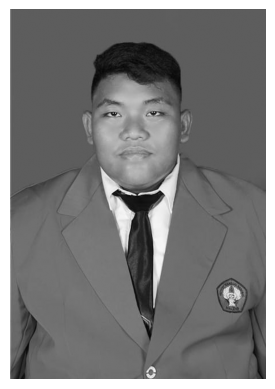

In [ ]:
single_face = os.path.join(path,"single_face.jpeg")
img = cv2.imread(single_face, 0)

plt.axis('off')
plt.imshow(img, cmap='gray')

### b. Proses Deteksi Wajah pada Citra Single Face

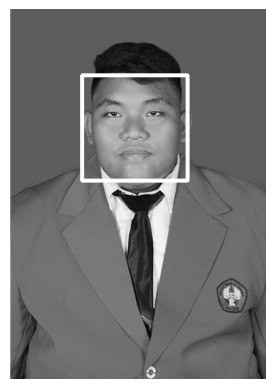

In [ ]:
# Memuat Haar Cascade Wajah
haarcascades = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(haarcascades)

# Proses deteksi wajah
deteksi_wajah = face_cascade.detectMultiScale(img)

# Memberikan Kotak Pembatas
for(x,y,w,h) in deteksi_wajah:
    cv2.rectangle(img,
                 (x,y),
                 (x+w, y+h),
                 (255,255,255),
                 5)

# Menampilkan gambar dengan wajah yang sudah dideteksi dan diberi pembatas
plt.axis('off')
plt.imshow(img, cmap='gray')

# **Deteksi Banyak Wajah dan Blur Wajah**

### a. Membaca dan Menampilkan Gambar Multi Face

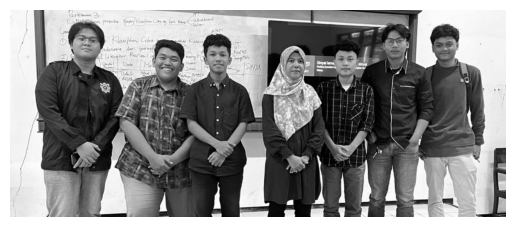

In [ ]:
many_faces = os.path.join(path,"many_face.jpeg")
img = cv2.imread(many_faces, 0)

plt.axis('off')
plt.imshow(img, cmap='gray')

### b. Proses Deteksi Wajah pada Citra Multi Faces

(np.float64(-0.5), np.float64(1054.5), np.float64(440.5), np.float64(-0.5))

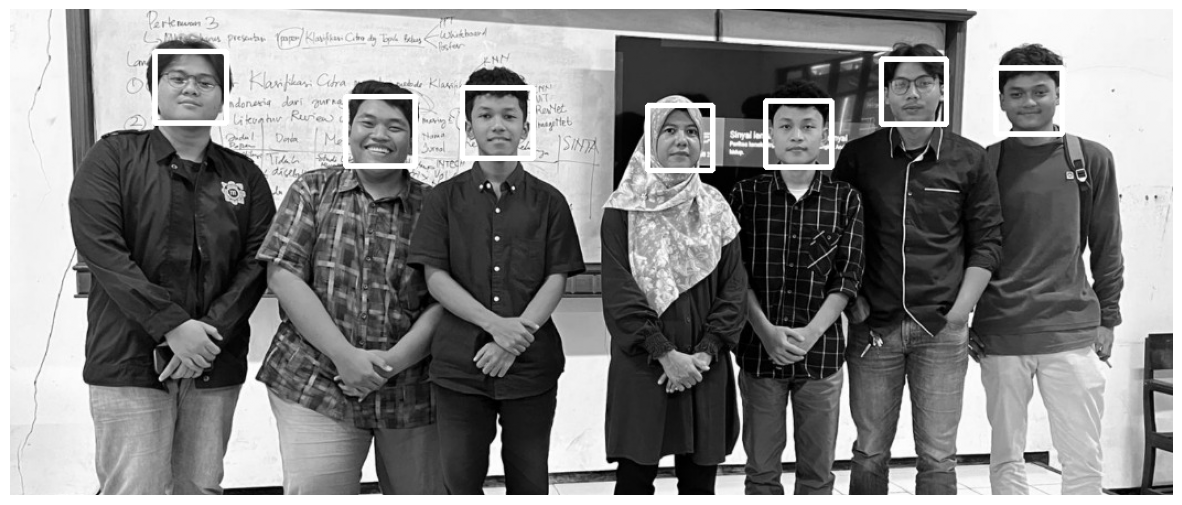

In [ ]:
# Memuat Haar Cascade Wajah
haarcascades = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(haarcascades)

# Proses deteksi wajah dengan beberapa parameter tambahan
deteksi_wajah = face_cascade.detectMultiScale(
    img,
    scaleFactor=1.145,
    minNeighbors=7
)

# Memberikan Kotak Pembatas
for(x, y, w, h) in deteksi_wajah:
        cv2.rectangle(img, (x,y), (x+w, y+h), (255), 3)

# Menampilkan gambar dengan wajah yang sudah dideteksi dan diberi pembatas
plt.figure(figsize=(15,10))
plt.imshow(img, cmap='gray')
plt.axis('off')

### c. Deteksi Wajah dengan Citra Multi Faces Lain

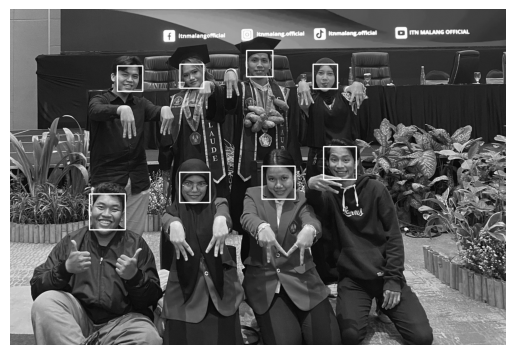

In [ ]:
# Membaca gambar yang berisi banyak wajah dari folder dataset
many = os.path.join(path,"multi_face.jpeg")
img = cv2.imread(many, 0)

# Memuat Haar Cascade Classifier untuk deteksi wajah
haarcascades = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(haarcascades)

# Melakukan proses deteksi banyak wajah pada gambar
deteksi_wajah = face_cascade.detectMultiScale(
                                               img,
                                               scaleFactor=1.146,
                                               minNeighbors=7,
                                               minSize=(90,90))

# Memberikan kotak pembatas pada setiap wajah yang berhasil dideteksi
for(x,y,w,h) in deteksi_wajah:
    cv2.rectangle(img,
                 (x,y),
                 (x+w, y+h),
                 (255,255,255),
                 5)

# Menampilkan hasil gambar setelah proses deteksi wajah
plt.axis('off')
plt.imshow(img, cmap='gray')

### d. Menerapkan Blur pada Citra Multi Faces

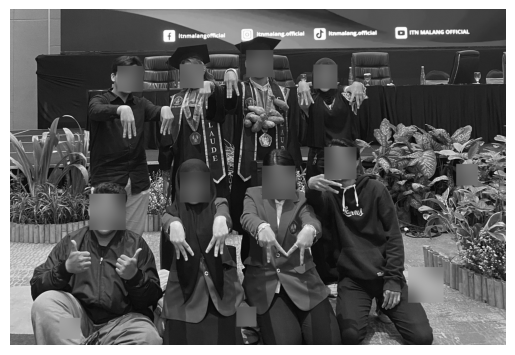

In [ ]:
# Membaca gambar yang berisi banyak wajah dari folder dataset
many = os.path.join(path,"multi_face.jpeg")
img = cv2.imread(many, 0)

# Memuat Haar Cascade Classifier untuk deteksi wajah
haarcascades = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(haarcascades)

# Melakukan proses deteksi banyak wajah pada gambar
deteksi_wajah = face_cascade.detectMultiScale(
                                               img,
                                               scaleFactor=1.04,
                                               minNeighbors=8,
                                               minSize=(90,90))

# Memberikan efek blur pada setiap wajah yang berhasil dideteksi
for (x, y, w, h) in deteksi_wajah:
    target = img[y:y+h, x:x+w]
    blur = cv2.GaussianBlur(target, (251, 251), 0)
    img[y:y+h, x:x+w] = blur

# Menampilkan hasil gambar setelah wajah diberikan efek blur
plt.axis('off')
plt.imshow(img, cmap='gray')

# **Deteksi Plat Nomor Menggunakan Haar**

### a. Persiapkan Gambar Nomor Plat Mobil

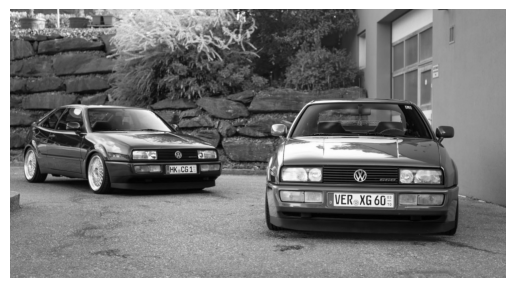

In [ ]:
car_plate = os.path.join(path, 'plate_car.jpeg')
img = cv2.imread(car_plate, 0)

plt.axis('off')
plt.imshow(img, cmap='gray')

### b. Deteksi bagian nomor plat dari gambar mobil

(705, 1302)


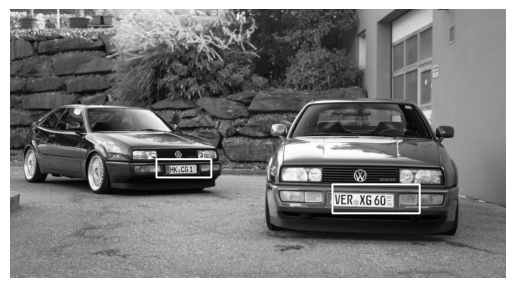

In [ ]:
img2 = img.copy()
print(img2.shape)

# Load Haar Cascade plat nomor
haarcascades = cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml'
plat_cascade = cv2.CascadeClassifier(haarcascades)

deteksi_plate = plat_cascade.detectMultiScale(
    img2,
    scaleFactor=1.01,
    minNeighbors=25,
    minSize=(30, 10)
)

# berikan kotak pembatas pada nomor plat yang terdeteksi
for(x,y,w,h) in deteksi_plate:
    cv2.rectangle(img2, (x,y), (x+w, y+h), (255), 3)

plt.axis('off')
plt.imshow(img2, cmap='gray')

### c. Blur atau kaburkan nomor plat yang telah terdeteksi

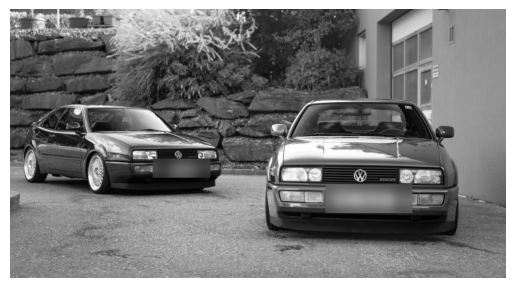

In [ ]:
# Kaburkan atau blur nomor plat
img3 = img.copy()

deteksi_plate = plat_cascade.detectMultiScale(
    img2,
    scaleFactor=1.01,
    minNeighbors=25,
    minSize=(30, 10)
)

for(x,y,w,h) in deteksi_plate:
    target = img3[y:y+h, x:x+w]
    target = cv2.GaussianBlur(target, (101,101), 0)
    img3[y:y+h, x:x+w] = target

plt.axis('off')
plt.imshow(img3, cmap='gray')

### d. Ekstrak Nomor Plat dari gambar plat yang telah terdeteksi

(705, 1302)


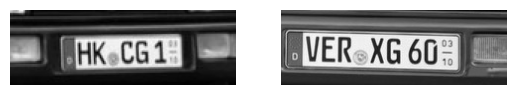

In [ ]:
#duplikasikan kembali gambar input
img4 = img.copy()

print(img4.shape)

#lakukan detekasi dengan plat_cascade yang sudah ada
deteksi_plate = plat_cascade.detectMultiScale(
    img2,
    scaleFactor=1.01,
    minNeighbors=25,
    minSize=(30, 10)
)

# Ambil potongan plat dari gambar
cropped_plate = []
for(x,y,w,h) in deteksi_plate:
    cropped_plate.append(img4[y:y+h, x:x+w])

# Lihat potongan plat
for i, plate in enumerate(cropped_plate):
    plt.subplot(1, len(cropped_plate), i + 1)
    plt.axis('off')
    plt.imshow(plate, cmap='gray')

plt.show()

### e. Hasil Pembacaan Plat Nomor Mobil

In [ ]:
import easyocr
reader = easyocr.Reader(['en'])

for plate in cropped_plate:

    th, plate = cv2.threshold(plate, 100, 255, cv2.THRESH_BINARY)
    # plate = cv2.blur(plate, (3,3))

    result = reader.readtext(plate)

    for (bbox, text, prob) in result:
      #  if prob > 0.70:
      #       (top_left, top_right, bottom_right, bottom_left) = bbox
            print(f'Text: {text}, Probability: {prob}')

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Text: [HK CG1, Probability: 0.2717536229035116
Text: VER, Probability: 0.9956505332134544
Text: XG 60, Probability: 0.9441918172935063
